In [3]:
# Install XGBoost (run once)
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 7.2 MB/s eta 0:00:14
   - -------------------------------------- 3.1/101.7 MB 7.9 MB/s eta 0:00:13
   -- ------------------------------------- 5.5/101.7 MB 9.1 MB/s eta 0:00:11
   -- ------------------------------------- 7.3/101.7 MB 9.2 MB/s eta 0:00:11
   --- ------------------------------------ 9.4/101.7 MB 9.4 MB/s eta 0:00:10
   ---- ----------------------------------- 11.5/101.7 MB 9.4 MB/s eta 0:00:10
   ----- ---------------------------------- 13.9/101.7 MB 9.6 MB/s eta 0:00:10
   ------ --------------------------------- 16.0/101.7 MB 9.8 MB/s eta 0:00:09
   ------- -------------------------------- 18.1/101.7 MB 9.9 MB/s eta 0:00:09
   ------- -------------------------------- 20.2/101.7 MB 9.9 MB/s eta 0:00:09
   -------- ------------------------------- 22.3/101.7 MB 10.0 MB/s eta 0:00:08
   --------- ------------------------------ 24.4/101.7 MB 10.0 M

In [4]:
# ============================================
# PROJECT 2: Late Delivery Risk Prediction
# Phase 7: Model Building
# Author: Mohan | Unified Mentor Internship
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import time
import joblib

# ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics (will use more in Phase 8)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

sns.set_style('whitegrid')

# Load prepared data from Phase 6
print("📥 Loading prepared datasets...")
X_train = joblib.load('../models/X_train_balanced.pkl')
X_test = joblib.load('../models/X_test_scaled.pkl')
y_train = joblib.load('../models/y_train_balanced.pkl')
y_test = joblib.load('../models/y_test.pkl')
feature_names = joblib.load('../models/feature_names.pkl')

print(f"\n✅ All data loaded successfully!")
print(f"📊 X_train shape: {X_train.shape}")
print(f"📊 X_test shape:  {X_test.shape}")
print(f"📊 y_train balance: {pd.Series(y_train).value_counts().to_dict()}")
print(f"📊 y_test balance:  {pd.Series(y_test).value_counts().to_dict()}")
print(f"📊 Features ({len(feature_names)}): {feature_names[:5]}...")

📥 Loading prepared datasets...

✅ All data loaded successfully!
📊 X_train shape: (158362, 32)
📊 X_test shape:  (36104, 32)
📊 y_train balance: {1: 79181, 0: 79181}
📊 y_test balance:  {1: 19796, 0: 16308}
📊 Features (32): ['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Latitude', 'Longitude']...


In [5]:
# ===== TRACKER FOR ALL MODEL RESULTS =====
# This dictionary will hold metrics for all 3 models
# We'll use it to compare and pick the winner

results = {}

def evaluate_quick(model_name, model, X_test, y_test):
    """Quick evaluation function - we'll do detailed eval in Phase 8"""
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1
    
    # Compute key metrics
    metrics = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_pred_proba)
    }
    
    # Print formatted output
    print(f"\n{'='*55}")
    print(f"{model_name} RESULTS")
    print(f"{'='*55}")
    for metric, value in metrics.items():
        print(f"   {metric:<12}: {value:.4f} ({value*100:.2f}%)")
    
    return metrics, y_pred, y_pred_proba

print("✅ Helper function defined. Ready to train models!")

✅ Helper function defined. Ready to train models!


In [6]:
# ===== MODEL 1: LOGISTIC REGRESSION =====
# This is our baseline — simple, fast, interpretable
# A good rule: if your fancy model can't beat Logistic Regression, you have a bug!

print("🚀 Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,          # Allow more iterations to converge
    random_state=42,        # Reproducibility
    n_jobs=-1               # Use all CPU cores
)

lr_model.fit(X_train, y_train)

elapsed = time.time() - start_time
print(f"✅ Training complete in {elapsed:.1f} seconds")

# Evaluate
results['Logistic Regression'], lr_pred, lr_proba = evaluate_quick(
    'LOGISTIC REGRESSION', lr_model, X_test, y_test
)

# Save the model
joblib.dump(lr_model, '../models/model_logistic_regression.pkl')
print("\n💾 Model saved: models/model_logistic_regression.pkl")

🚀 Training Logistic Regression...
✅ Training complete in 4.1 seconds

LOGISTIC REGRESSION RESULTS
   Accuracy    : 0.6964 (69.64%)
   Precision   : 0.8499 (84.99%)
   Recall      : 0.5419 (54.19%)
   F1 Score    : 0.6619 (66.19%)
   ROC-AUC     : 0.7412 (74.12%)

💾 Model saved: models/model_logistic_regression.pkl


In [7]:
# ===== MODEL 2: RANDOM FOREST =====
# Random Forest = 100 decision trees voting
# Handles nonlinear patterns much better than Logistic Regression
# Each tree sees a random subset of data and features

print("🚀 Training Random Forest...")
print("⏱️  Expected time: 3-8 minutes (this is normal!)")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,       # 100 trees in the forest
    max_depth=15,           # Limit depth to prevent overfitting
    min_samples_split=20,   # Need at least 20 samples to split a node
    random_state=42,
    n_jobs=-1,              # Use all CPU cores
    verbose=0
)

rf_model.fit(X_train, y_train)

elapsed = time.time() - start_time
print(f"✅ Training complete in {elapsed/60:.1f} minutes")

# Evaluate
results['Random Forest'], rf_pred, rf_proba = evaluate_quick(
    'RANDOM FOREST', rf_model, X_test, y_test
)

# Save the model
joblib.dump(rf_model, '../models/model_random_forest.pkl')
print("\n💾 Model saved: models/model_random_forest.pkl")

🚀 Training Random Forest...
⏱️  Expected time: 3-8 minutes (this is normal!)
✅ Training complete in 0.2 minutes

RANDOM FOREST RESULTS
   Accuracy    : 0.6984 (69.84%)
   Precision   : 0.8438 (84.38%)
   Recall      : 0.5521 (55.21%)
   F1 Score    : 0.6675 (66.75%)
   ROC-AUC     : 0.7504 (75.04%)

💾 Model saved: models/model_random_forest.pkl


In [8]:
# ===== MODEL 3: XGBoost =====
# XGBoost = Extreme Gradient Boosting
# Each new tree learns from the mistakes of previous trees
# Industry standard — wins most Kaggle competitions
# This is the model recruiters get excited about

print("🚀 Training XGBoost...")
print("⏱️  Expected time: 1-4 minutes")
start_time = time.time()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train, y_train)

elapsed = time.time() - start_time
print(f"✅ Training complete in {elapsed/60:.1f} minutes")

# Evaluate
results['XGBoost'], xgb_pred, xgb_proba = evaluate_quick(
    'XGBOOST', xgb_model, X_test, y_test
)

# Save the model
joblib.dump(xgb_model, '../models/model_xgboost.pkl')
print("\n💾 Model saved: models/model_xgboost.pkl")

🚀 Training XGBoost...
⏱️  Expected time: 1-4 minutes
✅ Training complete in 0.1 minutes

XGBOOST RESULTS
   Accuracy    : 0.7007 (70.07%)
   Precision   : 0.8158 (81.58%)
   Recall      : 0.5866 (58.66%)
   F1 Score    : 0.6825 (68.25%)
   ROC-AUC     : 0.7682 (76.82%)

💾 Model saved: models/model_xgboost.pkl


In [9]:
# ===== COMPARE ALL MODELS SIDE-BY-SIDE =====

# Convert results to DataFrame for easy comparison
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("="*65)
print("MODEL COMPARISON — ALL METRICS")
print("="*65)
print(results_df)

# Identify the winner (by ROC-AUC — most reliable metric for imbalanced data)
winner = results_df['ROC-AUC'].idxmax()
print(f"\n🏆 WINNER (by ROC-AUC): {winner}")
print(f"   ROC-AUC: {results_df.loc[winner, 'ROC-AUC']:.4f}")
print(f"   F1:      {results_df.loc[winner, 'F1 Score']:.4f}")
print(f"   Recall:  {results_df.loc[winner, 'Recall']:.4f}")

MODEL COMPARISON — ALL METRICS
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.6964     0.8499  0.5419    0.6619   0.7412
Random Forest          0.6984     0.8438  0.5521    0.6675   0.7504
XGBoost                0.7007     0.8158  0.5866    0.6825   0.7682

🏆 WINNER (by ROC-AUC): XGBoost
   ROC-AUC: 0.7682
   F1:      0.6825
   Recall:  0.5866


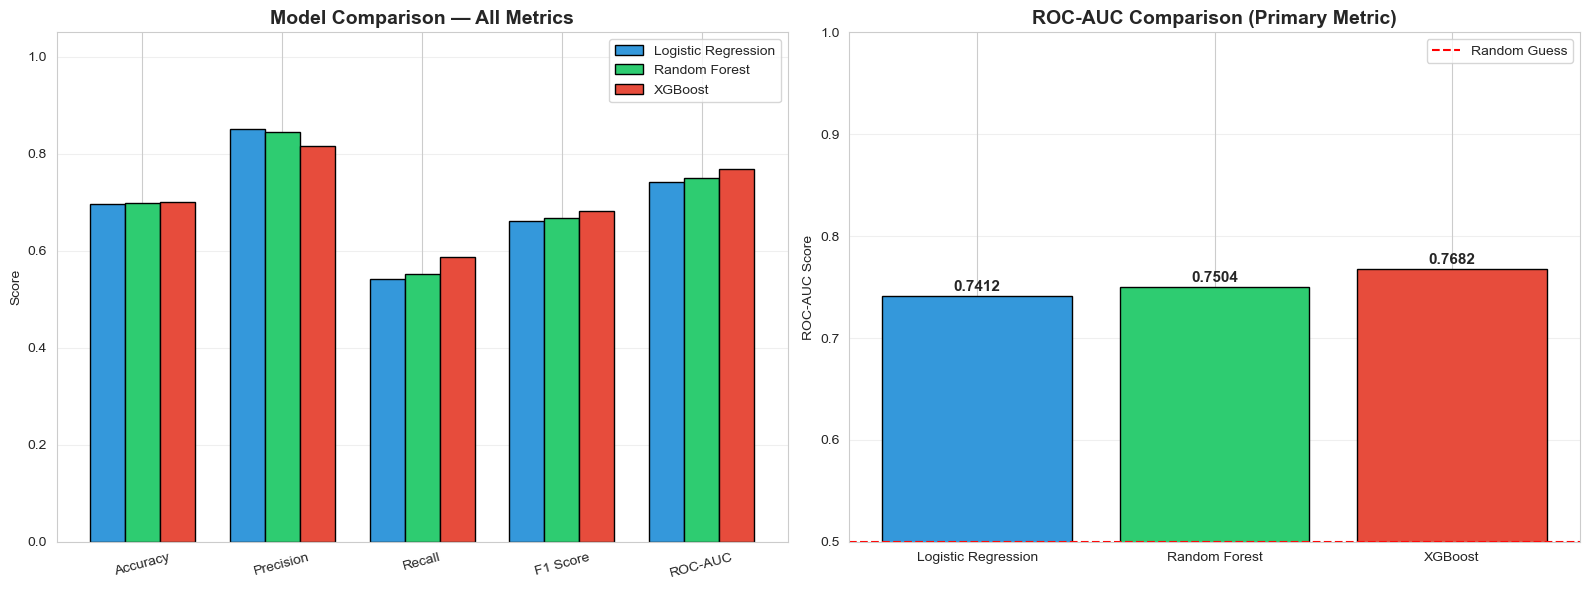


✅ Chart saved: charts/16_model_comparison.png


In [10]:
# ===== VISUALIZE MODEL COMPARISON =====

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Grouped bar chart of all metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x_pos = np.arange(len(metrics_to_plot))
width = 0.25

colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (model_name, color) in enumerate(zip(results.keys(), colors)):
    values = [results[model_name][m] for m in metrics_to_plot]
    axes[0].bar(x_pos + i*width, values, width, label=model_name, color=color, edgecolor='black')

axes[0].set_xticks(x_pos + width)
axes[0].set_xticklabels(metrics_to_plot, rotation=15)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: ROC-AUC alone (focus on the key metric)
roc_scores = [results[m]['ROC-AUC'] for m in results.keys()]
bars = axes[1].bar(results.keys(), roc_scores, color=colors, edgecolor='black')
axes[1].set_title('ROC-AUC Comparison (Primary Metric)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0.5, 1.0)
axes[1].axhline(y=0.5, color='red', linestyle='--', label='Random Guess')

# Add value labels
for bar, score in zip(bars, roc_scores):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                 f'{score:.4f}', ha='center', fontweight='bold', fontsize=11)

axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../charts/16_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: charts/16_model_comparison.png")

In [11]:
# ===== SELECT AND SAVE THE BEST MODEL =====
# Save the winner as 'best_model.pkl' for Streamlit to load

# Identify winner
winner_name = results_df['ROC-AUC'].idxmax()

model_map = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

best_model = model_map[winner_name]

# Save as the canonical "best" model
joblib.dump(best_model, '../models/best_model.pkl')

# Also save the winner name for Streamlit to display
with open('../models/best_model_name.txt', 'w') as f:
    f.write(winner_name)

print(f"🏆 BEST MODEL SELECTED: {winner_name}")
print(f"\n✅ Saved as: models/best_model.pkl")
print(f"✅ Name saved to: models/best_model_name.txt")

# Display final scoreboard
print(f"\n{'='*55}")
print(f"FINAL MODEL SCOREBOARD")
print(f"{'='*55}")
for model_name in results.keys():
    marker = "🏆" if model_name == winner_name else "  "
    auc = results[model_name]['ROC-AUC']
    f1 = results[model_name]['F1 Score']
    print(f"{marker} {model_name:<22} | AUC: {auc:.4f} | F1: {f1:.4f}")

🏆 BEST MODEL SELECTED: XGBoost

✅ Saved as: models/best_model.pkl
✅ Name saved to: models/best_model_name.txt

FINAL MODEL SCOREBOARD
   Logistic Regression    | AUC: 0.7412 | F1: 0.6619
   Random Forest          | AUC: 0.7504 | F1: 0.6675
🏆 XGBoost                | AUC: 0.7682 | F1: 0.6825


In [12]:
# ===== GENERATE RISK PROBABILITIES AND CATEGORIES =====
# Project requirement: each order needs probability + risk category

# Use best model to predict on test set
best_proba = best_model.predict_proba(X_test)[:, 1]  # Probability of LATE

# Categorize into Low / Medium / High Risk
def categorize_risk(prob):
    if prob < 0.40:
        return 'Low Risk'
    elif prob < 0.70:
        return 'Medium Risk'
    else:
        return 'High Risk'

# Apply categorization
risk_categories = pd.Series(best_proba).apply(categorize_risk)

# Show distribution
print("📊 RISK CATEGORY DISTRIBUTION (Test Set):")
print("="*45)
risk_dist = risk_categories.value_counts()
for cat in ['Low Risk', 'Medium Risk', 'High Risk']:
    count = risk_dist.get(cat, 0)
    pct = count / len(risk_categories) * 100
    print(f"   {cat:<15}: {count:>6,} orders ({pct:.1f}%)")

# Save predictions for analysis
predictions_df = pd.DataFrame({
    'Late_Probability': best_proba,
    'Risk_Category': risk_categories,
    'Actual_Late': y_test.values
})
predictions_df.to_csv('../data/test_predictions.csv', index=False)
print(f"\n💾 Predictions saved: data/test_predictions.csv")

📊 RISK CATEGORY DISTRIBUTION (Test Set):
   Low Risk       : 15,007 orders (41.6%)
   Medium Risk    : 10,011 orders (27.7%)
   High Risk      : 11,086 orders (30.7%)

💾 Predictions saved: data/test_predictions.csv


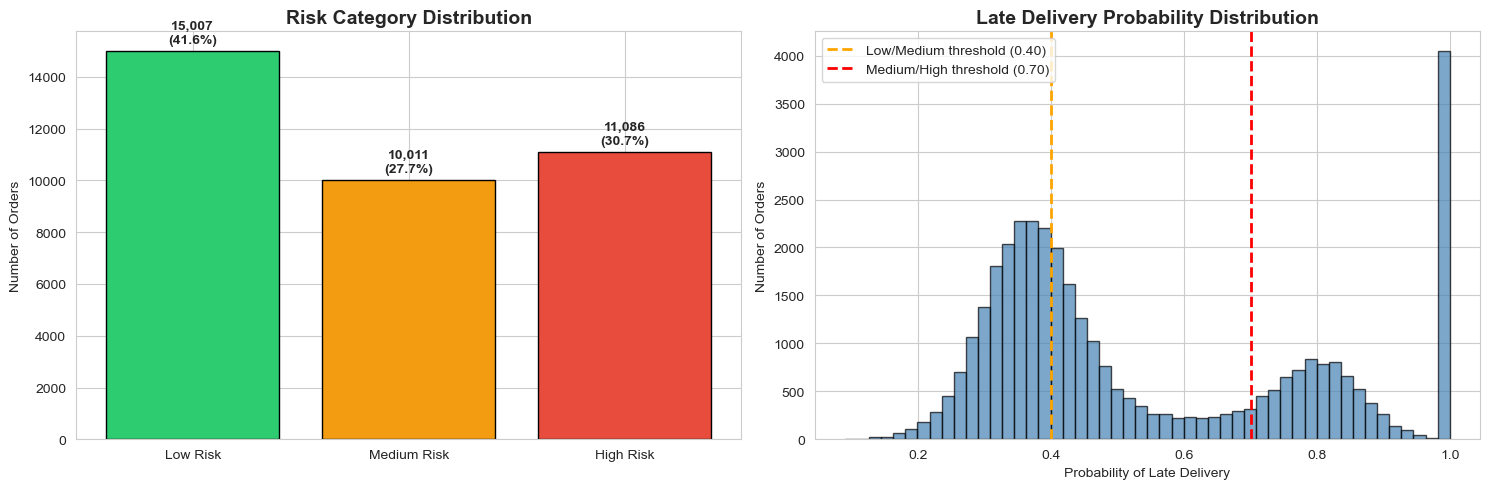


✅ Chart saved: charts/17_risk_distribution.png


In [13]:
# ===== VISUALIZE RISK CATEGORY DISTRIBUTION =====

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Bar chart of risk categories
risk_dist_ordered = risk_categories.value_counts().reindex(['Low Risk', 'Medium Risk', 'High Risk'])
colors_risk = ['#2ecc71', '#f39c12', '#e74c3c']

bars = axes[0].bar(risk_dist_ordered.index, risk_dist_ordered.values,
                    color=colors_risk, edgecolor='black')
axes[0].set_title('Risk Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Orders')

for bar, count in zip(bars, risk_dist_ordered.values):
    height = bar.get_height()
    pct = count / len(risk_categories) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 200,
                 f'{count:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')

# Plot 2: Probability distribution histogram
axes[1].hist(best_proba, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0.40, color='orange', linestyle='--', linewidth=2, label='Low/Medium threshold (0.40)')
axes[1].axvline(x=0.70, color='red', linestyle='--', linewidth=2, label='Medium/High threshold (0.70)')
axes[1].set_title('Late Delivery Probability Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Probability of Late Delivery')
axes[1].set_ylabel('Number of Orders')
axes[1].legend()

plt.tight_layout()
plt.savefig('../charts/17_risk_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved: charts/17_risk_distribution.png")

In [14]:
# Save phase 7 summary
summary = f"""
PHASE 7 SUMMARY — Model Building Complete
============================================

MODELS TRAINED: 3

1. LOGISTIC REGRESSION (Baseline)
   - Accuracy:  {results['Logistic Regression']['Accuracy']:.4f}
   - Precision: {results['Logistic Regression']['Precision']:.4f}
   - Recall:    {results['Logistic Regression']['Recall']:.4f}
   - F1 Score:  {results['Logistic Regression']['F1 Score']:.4f}
   - ROC-AUC:   {results['Logistic Regression']['ROC-AUC']:.4f}

2. RANDOM FOREST
   - Accuracy:  {results['Random Forest']['Accuracy']:.4f}
   - Precision: {results['Random Forest']['Precision']:.4f}
   - Recall:    {results['Random Forest']['Recall']:.4f}
   - F1 Score:  {results['Random Forest']['F1 Score']:.4f}
   - ROC-AUC:   {results['Random Forest']['ROC-AUC']:.4f}

3. XGBOOST
   - Accuracy:  {results['XGBoost']['Accuracy']:.4f}
   - Precision: {results['XGBoost']['Precision']:.4f}
   - Recall:    {results['XGBoost']['Recall']:.4f}
   - F1 Score:  {results['XGBoost']['F1 Score']:.4f}
   - ROC-AUC:   {results['XGBoost']['ROC-AUC']:.4f}

WINNER: {winner_name}
- Saved as: models/best_model.pkl
- Used for: Streamlit dashboard predictions

RISK CATEGORIZATION:
- Low Risk:    Probability < 0.40
- Medium Risk: Probability 0.40 - 0.70
- High Risk:   Probability >= 0.70

RISK DISTRIBUTION (TEST SET):
- Low Risk:    {risk_dist.get('Low Risk', 0):,} orders
- Medium Risk: {risk_dist.get('Medium Risk', 0):,} orders  
- High Risk:   {risk_dist.get('High Risk', 0):,} orders

FILES SAVED:
- models/model_logistic_regression.pkl
- models/model_random_forest.pkl
- models/model_xgboost.pkl
- models/best_model.pkl
- models/best_model_name.txt
- data/test_predictions.csv

READY FOR: Phase 8 — Detailed Model Evaluation
"""
print(summary)

with open('../phase7_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print("\n✅ Saved to phase7_summary.txt")


PHASE 7 SUMMARY — Model Building Complete

MODELS TRAINED: 3

1. LOGISTIC REGRESSION (Baseline)
   - Accuracy:  0.6964
   - Precision: 0.8499
   - Recall:    0.5419
   - F1 Score:  0.6619
   - ROC-AUC:   0.7412

2. RANDOM FOREST
   - Accuracy:  0.6984
   - Precision: 0.8438
   - Recall:    0.5521
   - F1 Score:  0.6675
   - ROC-AUC:   0.7504

3. XGBOOST
   - Accuracy:  0.7007
   - Precision: 0.8158
   - Recall:    0.5866
   - F1 Score:  0.6825
   - ROC-AUC:   0.7682

WINNER: XGBoost
- Saved as: models/best_model.pkl
- Used for: Streamlit dashboard predictions

RISK CATEGORIZATION:
- Low Risk:    Probability < 0.40
- Medium Risk: Probability 0.40 - 0.70
- High Risk:   Probability >= 0.70

RISK DISTRIBUTION (TEST SET):
- Low Risk:    15,007 orders
- Medium Risk: 10,011 orders  
- High Risk:   11,086 orders

FILES SAVED:
- models/model_logistic_regression.pkl
- models/model_random_forest.pkl
- models/model_xgboost.pkl
- models/best_model.pkl
- models/best_model_name.txt
- data/test_predi